# 03 — Phân tích kết quả

Notebook này tổng hợp các kết quả experiment chính của bài toán Speech Emotion Recognition trên RAVDESS. Mục tiêu là so sánh baseline, feature ablation, regularization và model cuối cùng dùng cho demo Streamlit.

## 1. Setup

In [11]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT         = Path('..').resolve()
RESULTS_PATH = ROOT / 'experiments' / 'results.csv'
FIGURE_DIR   = ROOT / 'report' / 'figures'
EXTERNAL_COMPARE_PATH = (
    ROOT / 'checkpoints' / 'external_compare_old_models'
    / 'external_compare_summary.csv'
)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.float_format', '{:.4f}'.format)

METRIC_COLS  = ['test_loss', 'test_acc', 'test_f1_macro', 'test_f1_weight']
FINAL_RUN    = 'cnn1d_mfcc_delta_ls005_adamw'
BASELINE_RUN = 'cnn1d_mfcc_baseline_organic'

RUN_ORDER = [
    'cnn1d_mfcc_baseline_organic',
    'cnn1d_mfcc_delta_fix1_organic',
    'cnn1d_mfcc_delta_ls005_do025_adam',
    'cnn1d_mfcc_delta_ls005_adamw',
]
RUN_LABELS = {
    'cnn1d_mfcc_baseline_organic':       'Baseline\n(MFCC + Adam)',
    'cnn1d_mfcc_delta_fix1_organic':      'Delta ablation\n(MFCC+\u0394 + Adam)',
    'cnn1d_mfcc_delta_ls005_do025_adam':  'Regularization\n(MFCC+\u0394 + Adam)',
    'cnn1d_mfcc_delta_ls005_adamw':       'Final model\n(MFCC+\u0394 + AdamW)',
}

## 2. Kết quả experiment chính

In [13]:
results = pd.read_csv(RESULTS_PATH)
results['_order'] = results['run_name'].map({r: i for i, r in enumerate(RUN_ORDER)})
results = results.sort_values('_order').drop(columns='_order').reset_index(drop=True)

display(
    results[['run_name', 'model', 'feature_type', *METRIC_COLS, 'notes']]
    .style
    .format({c: '{:.4f}' for c in METRIC_COLS})
)

,run_name,model,feature_type,test_loss,test_acc,test_f1_macro,test_f1_weight,notes
0,cnn1d_mfcc_baseline_organic,CNN1D,mfcc,0.8344,0.7315,0.7251,0.7312,Primary baseline: MFCC + Adam on current RAVDESS split
1,cnn1d_mfcc_delta_fix1_organic,CNN1D,mfcc_delta,0.9725,0.6435,0.6292,0.6416,Delta feature ablation: MFCC + delta + delta-delta with Adam
2,cnn1d_mfcc_delta_ls005_do025_adam,CNN1D,mfcc_delta,1.0244,0.6991,0.6895,0.6940,Regularization ablation: delta features + label smoothing 0.05 + dropout 0.25 + Adam
3,cnn1d_mfcc_delta_ls005_adamw,CNN1D,mfcc_delta,0.5792,0.9167,0.9145,0.9173,Final selected model: verified re-evaluation of delta features + label smoothing 0.05 + dropout 0.25 + AdamW


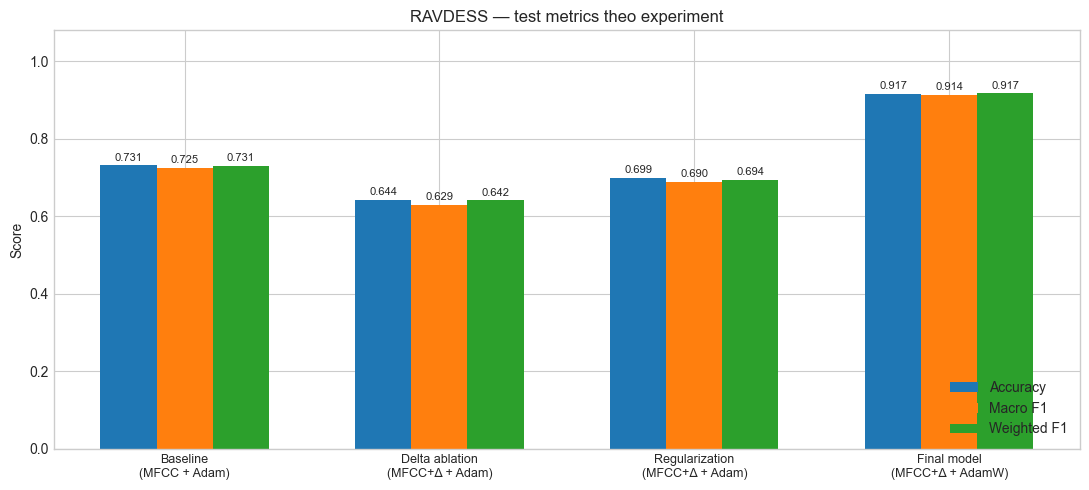

In [14]:
plot_df = results.copy()
plot_df['label'] = plot_df['run_name'].map(RUN_LABELS)

x   = np.arange(len(plot_df))
w   = 0.22
fig, ax = plt.subplots(figsize=(11, 5))

b1 = ax.bar(x - w, plot_df['test_acc'],       width=w, label='Accuracy')
b2 = ax.bar(x,     plot_df['test_f1_macro'],  width=w, label='Macro F1')
b3 = ax.bar(x + w, plot_df['test_f1_weight'], width=w, label='Weighted F1')

for bars in [b1, b2, b3]:
    ax.bar_label(bars, fmt='%.3f', fontsize=8, padding=2)

ax.set_xticks(x)
ax.set_xticklabels(plot_df['label'], fontsize=9)
ax.set_ylim(0, 1.08)
ax.set_ylabel('Score')
ax.set_title('RAVDESS — test metrics theo experiment')
ax.legend(loc='lower right')
fig.tight_layout()
plt.savefig(FIGURE_DIR / 'experiment_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Nhận xét

- **Baseline** (`MFCC + Adam`): 73.1% accuracy — mốc so sánh chính.
- **Delta ablation** (`MFCC+\u0394 + Adam`): giảm xuống 64.4%. Feature động học khó hội tụ hơn khi chưa có regularization phù hợp.
- **Regularization ablation** (`MFCC+\u0394 + LS 0.05 + DO 0.25 + Adam`): hồi phục lên 69.9% nhưng vẫn chưa vượt baseline.
- **Final model** (`MFCC+\u0394 + LS 0.05 + DO 0.25 + AdamW`): nhảy lên **91.7%** — cải thiện đến từ tổ hợp AdamW + regularization đúng mức + feature đầy đủ.

## 3. Mức cải thiện so với baseline

In [15]:
baseline = results.loc[results['run_name'] == BASELINE_RUN].iloc[0]

improvement = results[['run_name', 'test_acc', 'test_f1_macro', 'test_f1_weight']].copy()
improvement['\u0394 Accuracy']    = improvement['test_acc']       - baseline['test_acc']
improvement['\u0394 Macro F1']    = improvement['test_f1_macro']  - baseline['test_f1_macro']
improvement['\u0394 Weighted F1'] = improvement['test_f1_weight'] - baseline['test_f1_weight']

delta_cols = ['\u0394 Accuracy', '\u0394 Macro F1', '\u0394 Weighted F1']

display(
    improvement[['run_name', 'test_acc', *delta_cols]]
    .style
    .map(
        lambda v: 'color: green' if v > 0 else ('color: red' if v < 0 else ''),
        subset=delta_cols,
    )
    .format({'test_acc': '{:.4f}', **{c: '{:+.4f}' for c in delta_cols}})
)

,run_name,test_acc,Δ Accuracy,Δ Macro F1,Δ Weighted F1
0,cnn1d_mfcc_baseline_organic,0.7315,+0.0000,+0.0000,+0.0000
1,cnn1d_mfcc_delta_fix1_organic,0.6435,-0.0880,-0.0959,-0.0896
2,cnn1d_mfcc_delta_ls005_do025_adam,0.6991,-0.0324,-0.0356,-0.0371
3,cnn1d_mfcc_delta_ls005_adamw,0.9167,+0.1852,+0.1894,+0.1861


## 4. Confusion matrix — model cuối

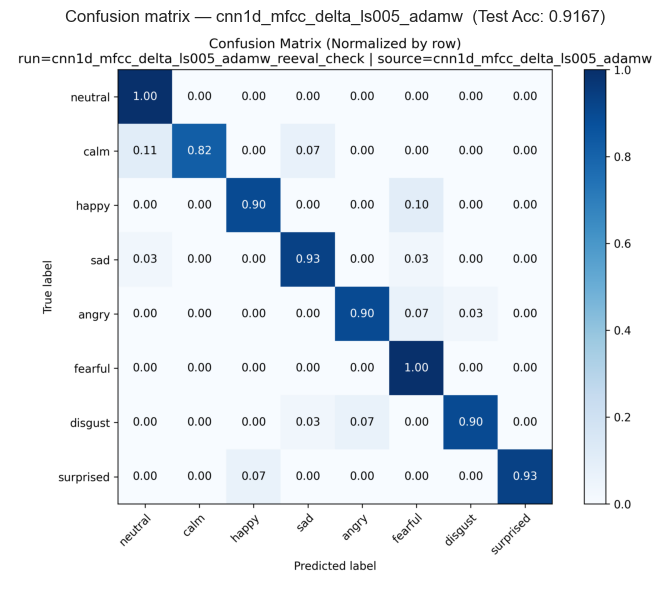

In [16]:
cm_path = FIGURE_DIR / f'confusion_matrix_{FINAL_RUN}.png'

if cm_path.exists():
    img = plt.imread(cm_path)
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.imshow(img)
    ax.axis('off')
    final_acc = results.loc[results['run_name'] == FINAL_RUN, 'test_acc'].values[0]
    ax.set_title(f'Confusion matrix — {FINAL_RUN}  (Test Acc: {final_acc:.4f})')
    fig.tight_layout()
    plt.show()
else:
    print(f'[!] Không tìm thấy: {cm_path}')
    print('    Chạy `uv run python -m src.evaluate` để sinh confusion matrix.')

## 5. External sanity check

> **Lưu ý:** Phần này **không phải benchmark chính**. TESS, SAVEE và `emotion_audio` có domain, ngôn ngữ và cách gán nhãn khác nhau — kết quả bên dưới chỉ dùng để kiểm tra sơ bộ khả năng generalize, không so sánh trực tiếp với RAVDESS.

In [18]:
if EXTERNAL_COMPARE_PATH.exists():
    external = pd.read_csv(EXTERNAL_COMPARE_PATH)
    external['run_label'] = external['run_name'].map(RUN_LABELS)
    display(external)
else:
    external = None
    print(f'[!] Không tìm thấy: {EXTERNAL_COMPARE_PATH}')

[!] Không tìm thấy: /Users/linhnguyen/Desktop/ser/checkpoints/external_compare_old_models/external_compare_summary.csv


In [19]:
if external is not None:
    pivot = external.pivot(index='dataset', columns='run_label', values='acc')
    col_order = [v for v in RUN_LABELS.values() if v in pivot.columns]
    pivot = pivot[col_order]

    display(pivot.style.format('{:.4f}').highlight_max(axis=1, color='#d4edda'))

    ax = pivot.plot(kind='bar', figsize=(11, 5), alpha=0.85)
    ax.set_ylim(0, 1.0)
    ax.set_ylabel('Accuracy')
    ax.set_title('External sanity check — accuracy theo dataset')
    ax.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    plt.show()

### Diễn giải external check

- **TESS**: Final AdamW có xu hướng tốt hơn baseline — TESS cũng là giọng diễn viên trong phòng thu, gần domain RAVDESS nhất.
- **SAVEE / emotion_audio**: Accuracy thấp hơn rõ rệt, cho thấy model phụ thuộc vào đặc trưng âm học của diễn viên RAVDESS (giọng Mỹ, cường độ cao). Domain mismatch là hạn chế chính.

## 6. Kết luận cho báo cáo

In [20]:
final_row    = results.loc[results['run_name'] == FINAL_RUN].iloc[0]
baseline_row = results.loc[results['run_name'] == BASELINE_RUN].iloc[0]

print('=== Model được chọn ===')
print(f'  Run       : {FINAL_RUN}')
print(f'  Feature   : {final_row["feature_type"]}')
print(f'  Test Acc  : {final_row["test_acc"]:.4f}  ({final_row["test_acc"] - baseline_row["test_acc"]:+.4f} vs baseline)')
print(f'  Macro F1  : {final_row["test_f1_macro"]:.4f}  ({final_row["test_f1_macro"] - baseline_row["test_f1_macro"]:+.4f} vs baseline)')
print(f'  Test loss : {final_row["test_loss"]:.4f}')
print()
print('=== Kết luận ===')
print("""
Model cnn1d_mfcc_delta_ls005_adamw được chọn làm model cuối sau khi re-evaluate
checkpoint đã lưu trên RAVDESS test set.

Cải thiện chính đến từ tổ hợp:
  1. MFCC + delta + delta-delta (120 chiều) — feature động học đầy đủ.
  2. Label smoothing 0.05 — giảm overconfidence.
  3. Dropout 0.25 — regularization phù hợp hơn 0.30.
  4. AdamW — decoupled weight decay hiệu quả hơn Adam với feature 120 chiều.

Hạn chế: model chưa generalize tốt sang domain khác (SAVEE, giọng thật).
Hướng tiếp theo: augmentation đa domain hoặc wav2vec2 / HuBERT backbone.
""")

=== Model được chọn ===
  Run       : cnn1d_mfcc_delta_ls005_adamw
  Feature   : mfcc_delta
  Test Acc  : 0.9167  (+0.1852 vs baseline)
  Macro F1  : 0.9145  (+0.1894 vs baseline)
  Test loss : 0.5792

=== Kết luận ===

Model cnn1d_mfcc_delta_ls005_adamw được chọn làm model cuối sau khi re-evaluate
checkpoint đã lưu trên RAVDESS test set.

Cải thiện chính đến từ tổ hợp:
  1. MFCC + delta + delta-delta (120 chiều) — feature động học đầy đủ.
  2. Label smoothing 0.05 — giảm overconfidence.
  3. Dropout 0.25 — regularization phù hợp hơn 0.30.
  4. AdamW — decoupled weight decay hiệu quả hơn Adam với feature 120 chiều.

Hạn chế: model chưa generalize tốt sang domain khác (SAVEE, giọng thật).
Hướng tiếp theo: augmentation đa domain hoặc wav2vec2 / HuBERT backbone.

